### Fast Data exploration step

In [ ]:
#import key modules
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

In [ ]:
# Reading CSV File
df = pd.read_csv("/content/Natural gas data.csv")
df

,Dates,Prices
0,10/31/20,10.10
1,11/30/20,10.30
2,12/31/20,11.00
3,1/31/21,10.90
4,2/28/21,10.90
5,3/31/21,10.90
6,4/30/21,10.40
7,5/31/21,9.84
8,6/30/21,10.00
9,7/31/21,10.10


In [ ]:
df.dtypes

,0
Dates,object
Prices,float64


In [ ]:
df["Dates"] = pd.to_datetime(df["Dates"], errors= "coerce")
df

/tmp/ipython-input-982/229909206.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"], errors= "coerce")


,Dates,Prices
0,2020-10-31,10.10
1,2020-11-30,10.30
2,2020-12-31,11.00
3,2021-01-31,10.90
4,2021-02-28,10.90
5,2021-03-31,10.90
6,2021-04-30,10.40
7,2021-05-31,9.84
8,2021-06-30,10.00
9,2021-07-31,10.10


In [ ]:
df.set_index("Dates")

,Prices
Dates,
2020-10-31,10.10
2020-11-30,10.30
2020-12-31,11.00
2021-01-31,10.90
2021-02-28,10.90
2021-03-31,10.90
2021-04-30,10.40
2021-05-31,9.84
2021-06-30,10.00


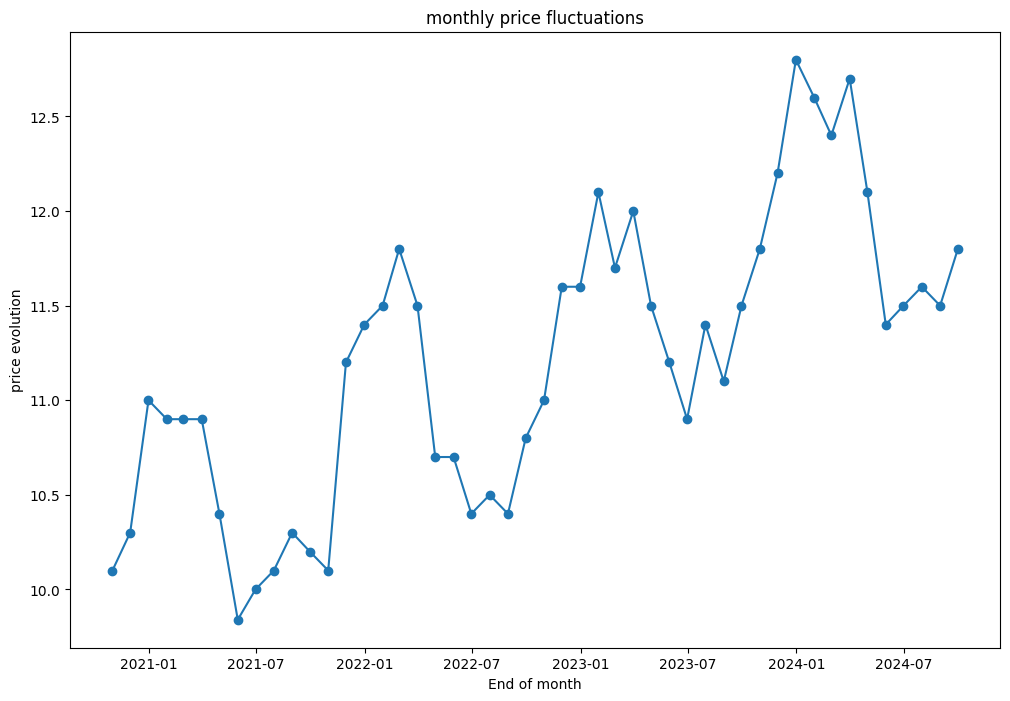

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(df["Dates"], df["Prices"], marker = 'o', linestyle='-')
plt.xlabel("End of month")
plt.ylabel("price evolution")
plt.title("monthly price fluctuations")
plt.show()

In [ ]:
type(df['Dates'].values.min())

numpy.datetime64

Based on the visualization of natural gas prices over these 48 months, we can see that overall, the average price of natural gas increases over time. However, a closer look reveals a downward trend during the spring season, while from November to the end of February, prices climb quite significantly during this period each year.

The possible causes could be related to:  

high winter demand (heating) combined with supply risks and lower European stocks

Creating the price estimation and extrapolation function:   

Let's develop a Python function that takes a specific date and DataFrame as input. This function will return an interpolated price for dates within the historical data range and an extrapolated price for dates up to one year after the last historical record, using an appropriate time series method.

In [ ]:
def estimer_prix(date, df_historique):
    """
    Estimates the gas price on a given date.

    Parameters:
    - date: target date (string 'YYYY-MM-DD' or datetime)
    - df_historique: DataFrame with datetime index and a 'price' column

    Returns:
    - estimated_price (float) or None if the date is outside the allowed window
    """
    # Convert the entry date to datetime
    if isinstance(date, str):
        date = pd.to_datetime(date)
    elif not isinstance(date, (pd.Timestamp, datetime)):
        raise ValueError("The date must be a string or a datetime object")

    # Retrieve the historical boundary markers
    dates_hist = pd.to_datetime(df_historique['Dates']).values
    prix_hist = df_historique['Prices'].values
    date_min = pd.Timestamp(dates_hist.min())
    date_max = pd.Timestamp(dates_hist.max())
    date_max_extrap = date_max + pd.DateOffset(years=1)

    # Verify that the date is within the allowed range
    if date < date_min or date > date_max_extrap:
        print(f"Date {date.date()} outside the allowed range ({date_min.date()} to {date_max_extrap.date()})")
        return None

    # 1. CASE: date within the historical range -> linear interpolation
    if date_min <= date <= date_max:
        # Convert dates to timestamps for numerical interpolation
        timestamps_hist = dates_hist.astype(np.int64) // 10**9
        timestamp_cible = date.timestamp()

        # Linear interpolation
        prix_interpole = np.interp(timestamp_cible, timestamps_hist, prix_hist)
        return prix_interpole

    # 2. CASE: date within the extrapolation window
    else:
        # Convert to pandas series to use .dt.days safely
        jours_hist = (pd.to_datetime(dates_hist) - date_min).days.values.astype(float)

        # Linear adjustment: price = a * days + b
        a, b = np.polyfit(jours_hist, prix_hist, 1)

        # Calculate the number of days for the target date
        jours_cible = (date - date_min).days

        # Extrapolated price
        prix_extrapole = a * jours_cible + b
        return prix_extrapole

In [ ]:
estimer_prix("2024-11-30", df)

np.float64(12.203060161703773)

In [ ]:
estimer_prix("2023-11-15", df)

np.float64(12.0)